### 1. Setup and Imports

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.linalg import expm
from typing import Dict, Tuple, List
import copy
import time

### 2. Mission Graph and Phase Logic
Defining the phase transitions (1 -> 2 -> 3 -> 4) and the rescue branch (R). Phase dependencies indicate which components must survive to pass the phase.


In [2]:
mission_diagram = {
    '1': {'success': '2', 'fail': 'R'},
    '2': {'success': '3', 'fail': 'R'},
    '3': {'success': '4', 'fail': 'R'},
    '4': {'success': 2,   'fail': 'R'},   # 2 = Mission Success
    'R': {'success': 1,   'fail': 0}      # 1 = Crew Saved, 0 = Total Loss
}

phase_component_logic = {
    '1': [{'A': 'survive', 'B': 'survive'}],
    '2': [{'A': 'survive', 'C': 'survive'}],
    '3': [{'A': 'survive', 'C': 'survive'}],
    '4': [{'A': 'survive', 'D': 'survive'}],
    'R': [{'E': 'survive', 'F': 'survive'}]
}

### 3. Dynamic Path Generator
Uses DFS to dynamically generate temporal boolean paths for the Markov engine, eliminating the need to hardcode BDD logic.

In [3]:
class DynamicPathGenerator:
    def __init__(self, mission_graph: Dict, phase_bdds: Dict):
        self.mission_graph = mission_graph
        self.phase_bdds = phase_bdds
        self.final_paths = {2: [], 1: [], 0: []}

    def _merge_conditions(self, current_path: Dict, new_phase: str, phase_reqs: Dict, is_phase_success: bool) -> Dict:
        new_path = copy.deepcopy(current_path)
        for comp, state in phase_reqs.items():
            if comp not in new_path:
                new_path[comp] = {'survives': [], 'fails': []}
            if state == 'survive':
                new_path[comp]['survives'].append(new_phase)
            elif state == 'fail':
                new_path[comp]['fails'].append(new_phase)

        if not is_phase_success:
            for comp, state in phase_reqs.items():
                if state == 'survive' and new_phase not in new_path[comp]['fails']:
                    new_path[comp]['fails'].append(new_phase)
        return new_path

    def generate_paths(self, current_phase: str, current_path: Dict = None):
        if current_path is None: current_path = {}

        if current_phase in [2, 1, 0]:
            clean_path = {c: {k: v for k, v in reqs.items() if v} for c, reqs in current_path.items()}
            self.final_paths[current_phase].append(clean_path)
            return

        transitions = self.mission_graph.get(current_phase, {})
        bdds = self.phase_bdds.get(current_phase, [])

        if 'success' in transitions:
            for bdd_path in bdds:
                next_path = self._merge_conditions(current_path, current_phase, bdd_path, True)
                self.generate_paths(transitions['success'], next_path)

        if 'fail' in transitions:
            for bdd_path in bdds:
                next_path = self._merge_conditions(current_path, current_phase, bdd_path, False)
                self.generate_paths(transitions['fail'], next_path)

        return self.final_paths

### 4. Baseline Hardware Specifications
Includes standard components constraints and switch failure rates (`lambda_s` and `rho_fail`). No environmental modifiers are applied here.

In [4]:
phase_durations = {'1': 100.0, '2': 50.0, '3': 150.0, '4': 100.0, 'R': 50.0}

component_specs = {
    'A': {'K': 4, 'lambda_c': 1/1500, 'weight': 5.0,  'cost': 10.0, 'lambda_s': 1/5000, 'rho_fail': 0.005},
    'B': {'K': 1, 'lambda_c': 1/1200, 'weight': 20.0, 'cost': 15.0, 'lambda_s': 1/8000, 'rho_fail': 0.001},
    'C': {'K': 1, 'lambda_c': 1/1535, 'weight': 10.0, 'cost': 8.0,  'lambda_s': 1/4000, 'rho_fail': 0.020},
    'D': {'K': 1, 'lambda_c': 1/1800, 'weight': 15.0, 'cost': 12.0, 'lambda_s': 1/6000, 'rho_fail': 0.008},
    'E': {'K': 5, 'lambda_c': 1/1200, 'weight': 25.0, 'cost': 20.0, 'lambda_s': 1/5500, 'rho_fail': 0.010},
    'F': {'K': 1, 'lambda_c': 1/1200, 'weight': 25.0, 'cost': 20.0, 'lambda_s': 1/9000, 'rho_fail': 0.002}
}

### 5. Baseline Markov Engine
Evaluates chronological path probabilities using a standard CTMC.

In [5]:
class Baseline_PMS_Engine:
    def __init__(self, component_specs, phase_durations, state_paths):
        self.component_specs = component_specs
        self.phase_durations = phase_durations
        self.state_paths = state_paths

    def check_constraints(self, particle: Dict, w_max: float, c_max: float) -> bool:
        total_w, total_c = 0.0, 0.0
        for c, n in particle.items():
            total_parts = self.component_specs[c]['K'] + n[0] + n[1]
            total_w += self.component_specs[c]['weight'] * total_parts
            total_c += self.component_specs[c]['cost'] * total_parts
            if n[2] > n[0]: return False
        return total_w <= w_max and total_c <= c_max

    def _build_ctmc_matrix(self, comp_id: str, n_H: int, n_C: int, n_o: int) -> Tuple[np.ndarray, int]:
        specs = self.component_specs[comp_id]
        lam_c = specs['lambda_c']
        lam_s = specs.get('lambda_s', 0.0)
        rho_fail = specs.get('rho_fail', 0.0)

        size = n_H + n_C + 2
        Q = np.zeros((size, size))

        for i in range(size - 1):
            active_components = min(specs['K'] + n_H, specs['K'] + n_H + n_C - i)
            base_fail_rate = lam_c * active_components

            continuous_switch_fail = lam_s * n_o
            total_continuous_rate = base_fail_rate + continuous_switch_fail

            if i >= n_H and n_C > 0 and i < n_H + n_C:
                Q[i, i+1] = total_continuous_rate * (1.0 - rho_fail)
                Q[i, -1] += total_continuous_rate * rho_fail
            else:
                Q[i, i+1] = total_continuous_rate

        for i in range(size):
            Q[i, i] = -np.sum(Q[i, :])
        return Q, size

    def evaluate_path_probability(self, path_reqs: Dict, particle: Dict) -> float:
        path_prob = 1.0
        mission_order = ['1', '2', '3', '4', 'R']

        for comp_id, conditions in path_reqs.items():
            if comp_id not in particle: continue

            n_H, n_C, n_o = particle[comp_id]
            Q, size = self._build_ctmc_matrix(comp_id, n_H, n_C, n_o)

            P_current = np.zeros(size)
            P_current[0] = 1.0

            all_req_phases = conditions.get('survives', []) + conditions.get('fails', [])
            if not all_req_phases: continue
            last_req_idx = max(mission_order.index(p) for p in all_req_phases)

            for i in range(last_req_idx + 1):
                current_phase = mission_order[i]
                t = self.phase_durations[current_phase]

                # Standard exponential degradation
                P_next = np.dot(P_current, expm(Q * t))

                if current_phase in conditions.get('fails', []):
                    path_prob *= max(P_next[-1] - P_current[-1], 0.0)
                    break
                P_current = P_next

            if not conditions.get('fails', []):
                path_prob *= max(1.0 - P_current[-1], 0.0)

        return max(path_prob, 0.0)

    def calculate_system_csp(self, particle: Dict, max_weight: float, max_cost: float) -> float:
        if not self.check_constraints(particle, max_weight, max_cost): return 0.0
        p_sys_2 = sum(self.evaluate_path_probability(path, particle) for path in self.state_paths.get(2, []))
        p_sys_1 = sum(self.evaluate_path_probability(path, particle) for path in self.state_paths.get(1, []))
        return min(p_sys_2 + p_sys_1, 1.0)

### 6. Optimizer (PSO) & Main Execution Block

1. Generating Paths via DFS...
2. Initializing Baseline Engine...
3. Starting Optimization...

Optimization Complete in 3.76s
Max Crew Survival Probability: 0.528128
  Component A: Hot=1, Cold=1, Online=0
  Component B: Hot=0, Cold=0, Online=0
  Component C: Hot=0, Cold=0, Online=0
  Component D: Hot=0, Cold=0, Online=0
  Component E: Hot=0, Cold=0, Online=0
  Component F: Hot=0, Cold=0, Online=0


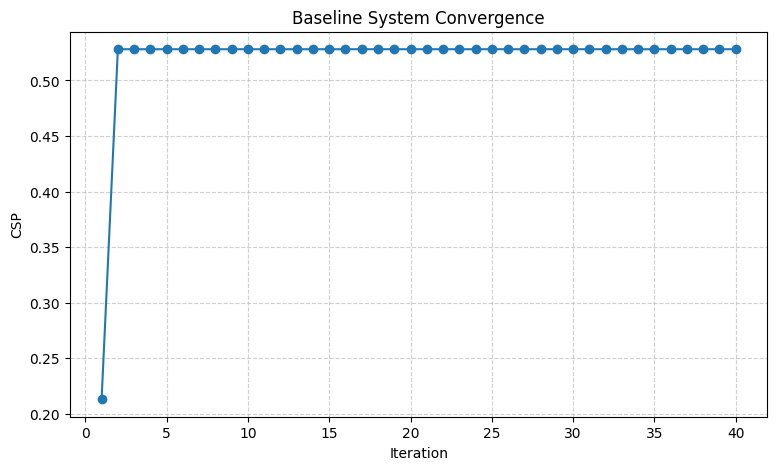

In [6]:
def run_baseline_pso(engine, num_particles=30, max_iter=40, w=0.5, c1=1.5, c2=1.5, max_weight=230.0, max_cost=220.0):
    start_time = time.time()
    component_ids = list(engine.component_specs.keys())

    swarm, velocities, pbest_positions, pbest_scores = [], [], [], []
    history = []

    base_config = {c: (0, 0, 0) for c in component_ids}
    gbest_position = base_config.copy()
    gbest_score = engine.calculate_system_csp(base_config, max_weight, max_cost)

    for i in range(num_particles):
        p_dict = {}
        for c in component_ids:
            if i == 0:
                p_dict[c] = (0, 0, 0)
            else:
                nH = random.randint(0, 1)
                nC = random.randint(0, 1)
                n_o = random.randint(0, nH)
                p_dict[c] = (nH, nC, n_o)

        swarm.append(p_dict)
        velocities.append([[0.0, 0.0, 0.0] for _ in component_ids])
        pbest_positions.append(p_dict.copy())
        pbest_scores.append(0.0)

    for iteration in range(max_iter):
        for i in range(num_particles):
            fitness = engine.calculate_system_csp(swarm[i], max_weight, max_cost)
            if fitness > pbest_scores[i]:
                pbest_scores[i] = fitness
                pbest_positions[i] = swarm[i].copy()
            if fitness > gbest_score:
                gbest_score = fitness
                gbest_position = swarm[i].copy()

        history.append(gbest_score)

        for i in range(num_particles):
            new_p = {}
            for j, c in enumerate(component_ids):
                curr, pbest, gbest = swarm[i][c], pbest_positions[i][c], gbest_position[c]
                new_pos = []
                for k in range(3):
                    r1, r2 = random.random(), random.random()
                    velocities[i][j][k] = (w * velocities[i][j][k] +
                                           c1 * r1 * (pbest[k] - curr[k]) +
                                           c2 * r2 * (gbest[k] - curr[k]))
                    val = max(0, int(round(curr[k] + velocities[i][j][k])))
                    new_pos.append(val)

                if new_pos[2] > new_pos[0]:
                    new_pos[2] = new_pos[0]

                new_p[c] = tuple(new_pos)
            swarm[i] = new_p

    exec_time = time.time() - start_time
    return gbest_position, gbest_score, history, exec_time

if __name__ == "__main__":
    print("1. Generating Paths via DFS...")
    generator = DynamicPathGenerator(mission_diagram, phase_component_logic)
    dynamic_paths = generator.generate_paths(current_phase='1')

    print("2. Initializing Baseline Engine...")
    baseline_engine = Baseline_PMS_Engine(component_specs, phase_durations, dynamic_paths)

    print("3. Starting Optimization...")
    best_config, best_csp, history, exec_time = run_baseline_pso(
        engine=baseline_engine, num_particles=30, max_iter=40, max_weight=230.0, max_cost=220.0
    )

    print(f"\nOptimization Complete in {exec_time:.2f}s")
    print(f"Max Crew Survival Probability: {best_csp:.6f}")
    for comp, config in best_config.items():
        print(f"  Component {comp}: Hot={config[0]}, Cold={config[1]}, Online={config[2]}")

    plt.figure(figsize=(9, 5))
    plt.plot(range(1, len(history) + 1), history, marker='o', color='#1f77b4')
    plt.title('Baseline System Convergence')
    plt.xlabel('Iteration')
    plt.ylabel('CSP')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()